# Assignment 1

## Smoothing filters 

In [2]:
import numpy as np

ecg_data = np.load("signal_sources/ECG_template.npz")

sampling_frequency = 500  # Hz
amplitude_units = "mV"

print("Available arrays:", ecg_data.files)

Available arrays: ['ECG_template']


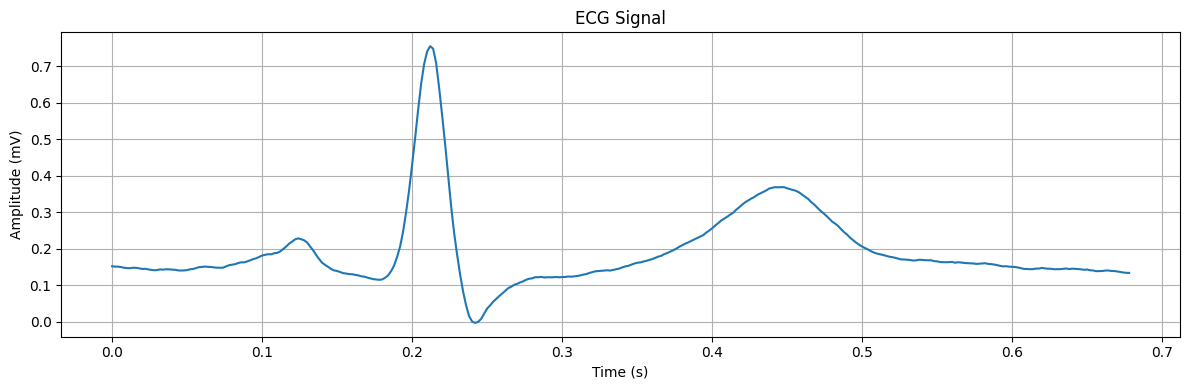

In [3]:
import matplotlib.pyplot as plt

ecg_signal = np.asarray(ecg_data["ECG_template"]).squeeze()
time = np.arange(ecg_signal.size) / sampling_frequency

plt.figure(figsize=(12, 4))
plt.plot(time, ecg_signal)
plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("ECG Signal")
plt.grid(True)
plt.tight_layout()
plt.show()

In [4]:
target_snr_db = 5

signal_power = np.mean(ecg_signal**2)
target_noise_power = signal_power / (10 ** (target_snr_db / 10))

noise = np.random.randn(ecg_signal.size)
noise *= np.sqrt(target_noise_power / np.mean(noise**2))

nECG = ecg_signal + noise

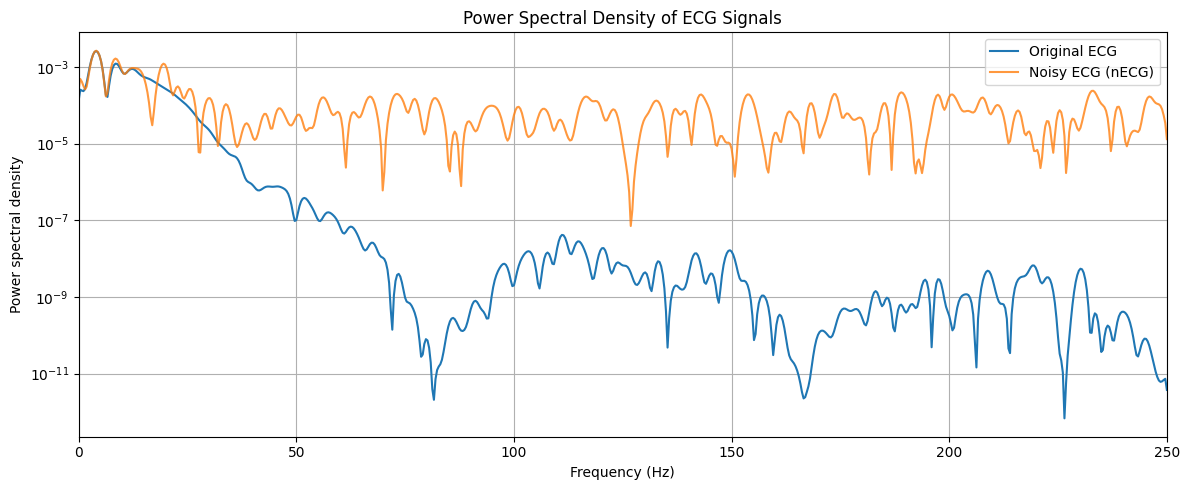

In [5]:
from scipy.signal import periodogram

nfft = 4 * len(ecg_signal)

frequencies, psd_ecg = periodogram(
    ecg_signal,
    fs=sampling_frequency,
    window="hann",
    nfft=nfft
)

_, psd_nECG = periodogram(
    nECG,
    fs=sampling_frequency,
    window="hann",
    nfft=nfft
)

plt.figure(figsize=(12, 5))
plt.semilogy(frequencies, psd_ecg, label="Original ECG")
plt.semilogy(frequencies, psd_nECG, label="Noisy ECG (nECG)", alpha=0.8)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("Power Spectral Density of ECG Signals")
plt.xlim(0, sampling_frequency / 2)
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### MA(3) filter implementation with a custom function

In [6]:
def ma3_filter(signal):
    """Apply a causal 3-point moving-average filter."""
    signal = np.asarray(signal)
    filtered = np.zeros_like(signal, dtype=float)

    for n in range(signal.size):
        start = max(0, n - 2)
        filtered[n] = np.mean(signal[start:n + 1])

    return filtered


ma3ECG_1 = ma3_filter(nECG)

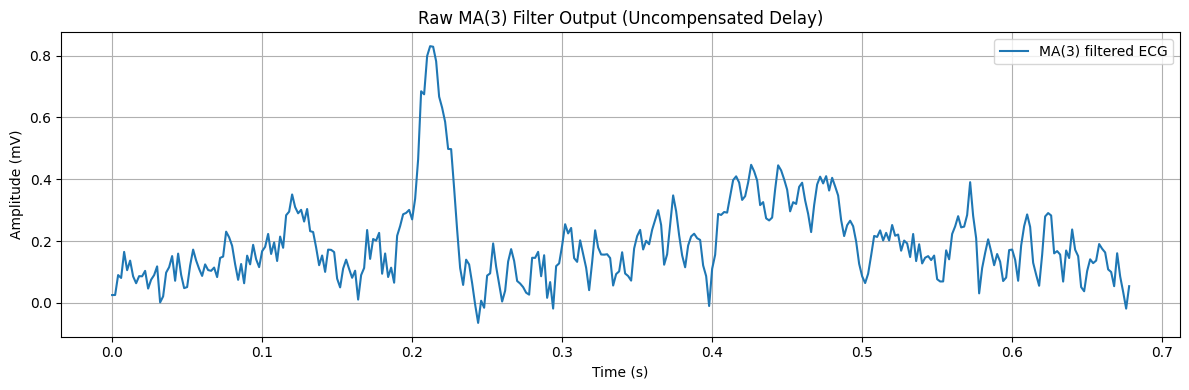

In [7]:
plt.figure(figsize=(12, 4))
plt.plot(time, ma3ECG_1, label="MA(3) filtered ECG")
plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Raw MA(3) Filter Output (Uncompensated Delay)")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

For an MA($N$) filter, the group delay is given by

$$
\tau_g = \frac{N - 1}{2}
$$

where $N$ is the number of filter coefficients. For the MA(3) filter:

$$
\tau_g = \frac{3 - 1}{2} = 1 \text{ sample}
$$

With a sampling frequency of $500$ Hz, the corresponding time delay is

$$
\tau_g = \frac{1}{500} = 0.002 \text{ s}
$$

Therefore, the filtered ECG signal is delayed by one sample, or 2 ms. This delay should be compensated when comparing the filtered signal with the original ECG signal.

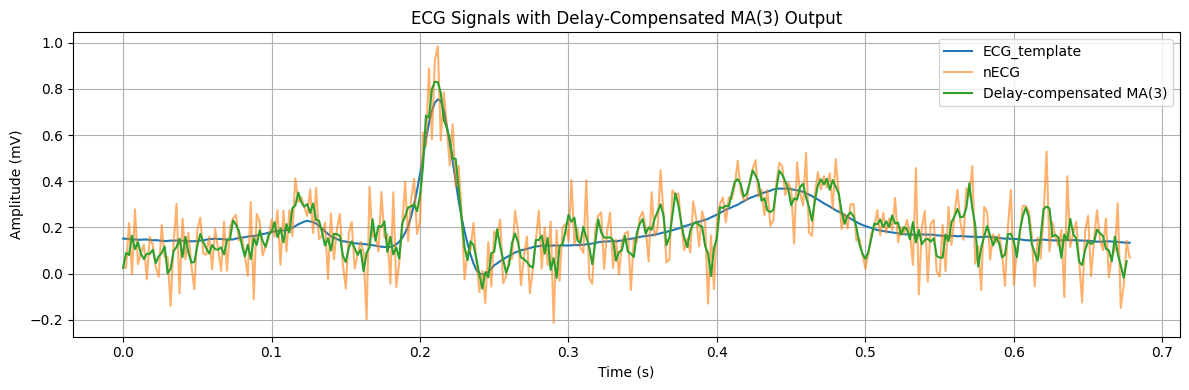

In [10]:
plt.figure(figsize=(12, 4))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, nECG, label="nECG", alpha=0.6)
plt.plot(time[:-1], ma3ECG_1[1:], label="Delay-compensated MA(3)", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("ECG Signals with Delay-Compensated MA(3) Output")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

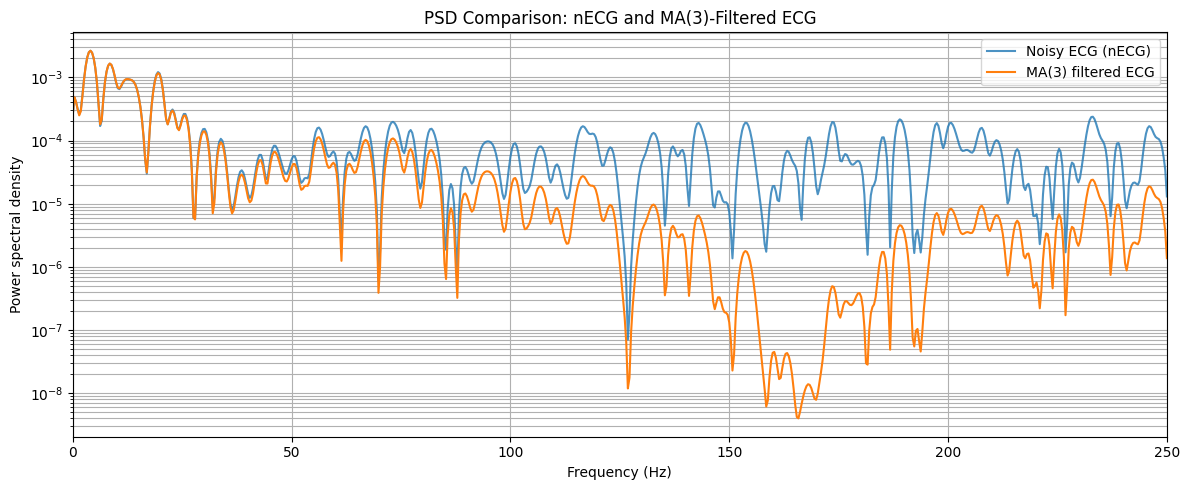

In [11]:
frequencies_ma3, psd_ma3ECG_1 = periodogram(
    ma3ECG_1,
    fs=sampling_frequency,
    window="hann",
    nfft=nfft
)

plt.figure(figsize=(12, 5))
plt.semilogy(frequencies, psd_nECG, label="Noisy ECG (nECG)", alpha=0.8)
plt.semilogy(
    frequencies_ma3,
    psd_ma3ECG_1,
    label="MA(3) filtered ECG",
    linewidth=1.5
)

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("PSD Comparison: nECG and MA(3)-Filtered ECG")
plt.xlim(0, sampling_frequency / 2)
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

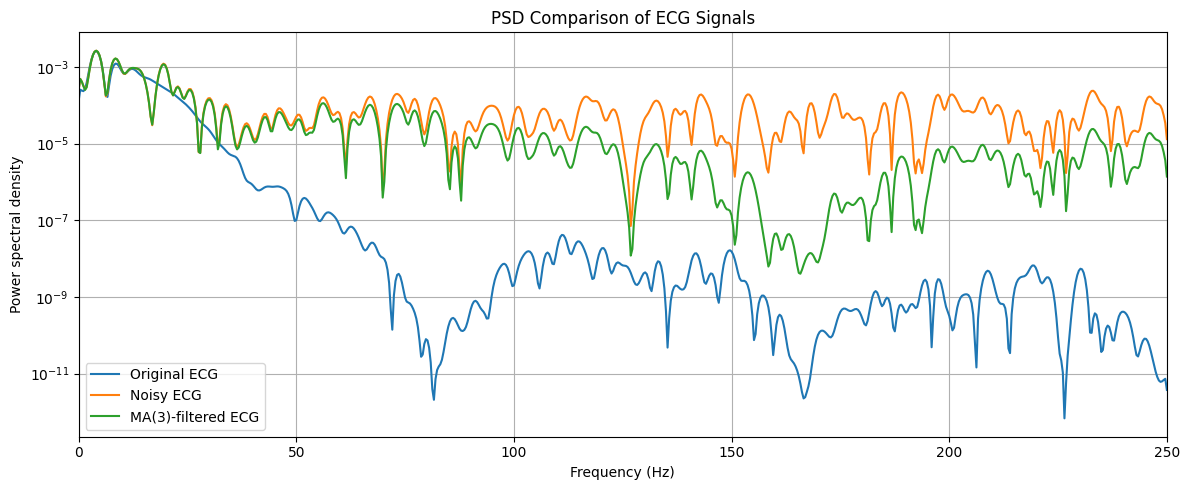

In [15]:
plt.figure(figsize=(12, 5))

plt.semilogy(frequencies, psd_ecg, label="Original ECG")
plt.semilogy(frequencies, psd_nECG, label="Noisy ECG")
plt.semilogy(frequencies_ma3, psd_ma3ECG_1, label="MA(3)-filtered ECG")

plt.xlabel("Frequency (Hz)")
plt.ylabel("Power spectral density")
plt.title("PSD Comparison of ECG Signals")
plt.xlim(0, sampling_frequency / 2)
plt.grid(True, which="both")
plt.legend()
plt.tight_layout()
plt.show()

### MA(3) filter implementation with a built-in function

In [17]:
from scipy.signal import lfilter

b = np.ones(3) / 3
a = np.array([1.0])

ma3ECG_lfilter = lfilter(b, a, nECG)

# Compensate for the one-sample group delay
ma3ECG_2 = ma3ECG_lfilter[1:]

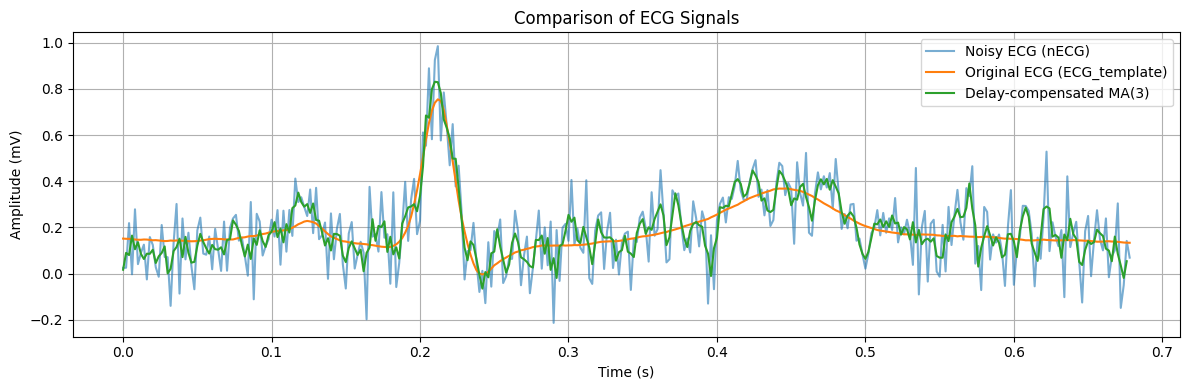

In [18]:
plt.figure(figsize=(12, 4))

plt.plot(time, nECG, label="Noisy ECG (nECG)", alpha=0.6)
plt.plot(time, ecg_signal, label="Original ECG (ECG_template)", linewidth=1.5)
plt.plot(
    time[:-1],
    ma3ECG_2,
    label="Delay-compensated MA(3)",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of ECG Signals")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

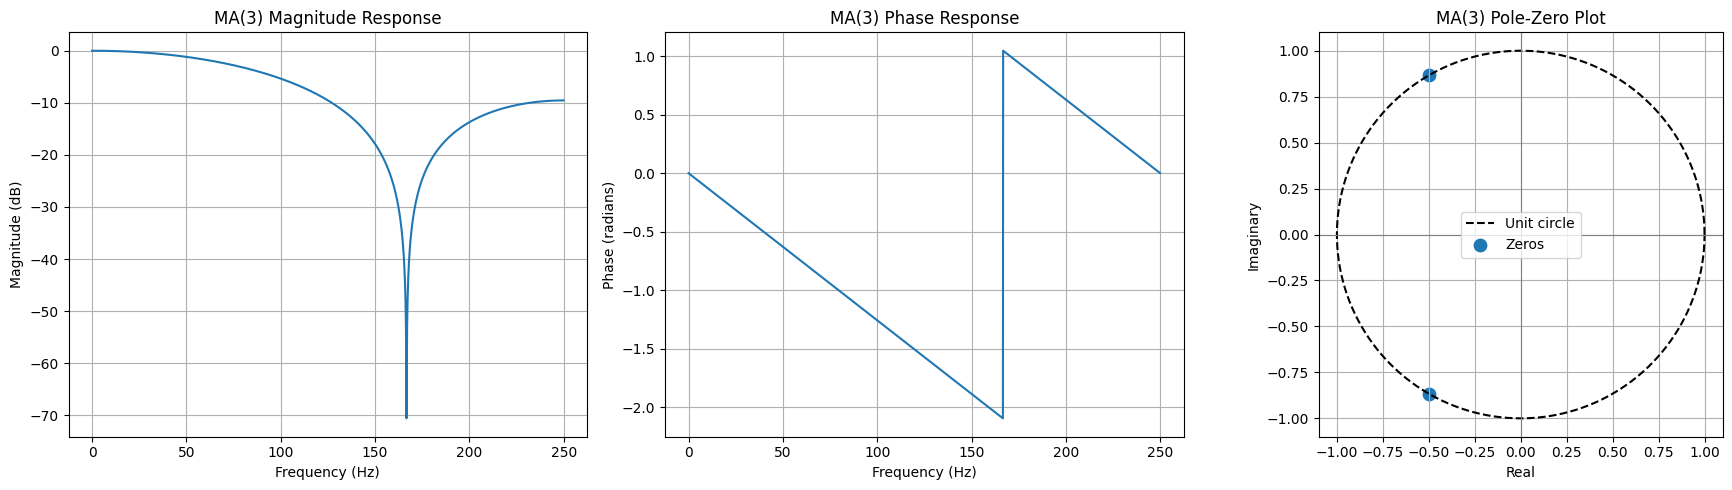

Zeros: [-0.5+0.8660254j -0.5-0.8660254j]
Poles: []


In [19]:
from scipy.signal import freqz

# Frequency and phase response
w, h = freqz(b, a, worN=2048, fs=sampling_frequency)

magnitude_db = 20 * np.log10(np.maximum(np.abs(h), np.finfo(float).eps))
phase = np.unwrap(np.angle(h))

# Zeros and poles
zeros = np.roots(b)
poles = np.roots(a)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Magnitude response
axes[0].plot(w, magnitude_db)
axes[0].set_title("MA(3) Magnitude Response")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].grid(True)

# Phase response
axes[1].plot(w, phase)
axes[1].set_title("MA(3) Phase Response")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (radians)")
axes[1].grid(True)

# Pole-zero plot
theta = np.linspace(0, 2 * np.pi, 500)
axes[2].plot(np.cos(theta), np.sin(theta), "k--", label="Unit circle")
axes[2].scatter(zeros.real, zeros.imag, marker="o", s=80, label="Zeros")

if poles.size:
    axes[2].scatter(
        poles.real,
        poles.imag,
        marker="x",
        s=80,
        linewidths=2,
        label="Poles"
    )

axes[2].axhline(0, color="gray", linewidth=0.8)
axes[2].axvline(0, color="gray", linewidth=0.8)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("MA(3) Pole-Zero Plot")
axes[2].set_xlabel("Real")
axes[2].set_ylabel("Imaginary")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Zeros:", zeros)
print("Poles:", poles)

### MA(10) filter implementation with a built-in function

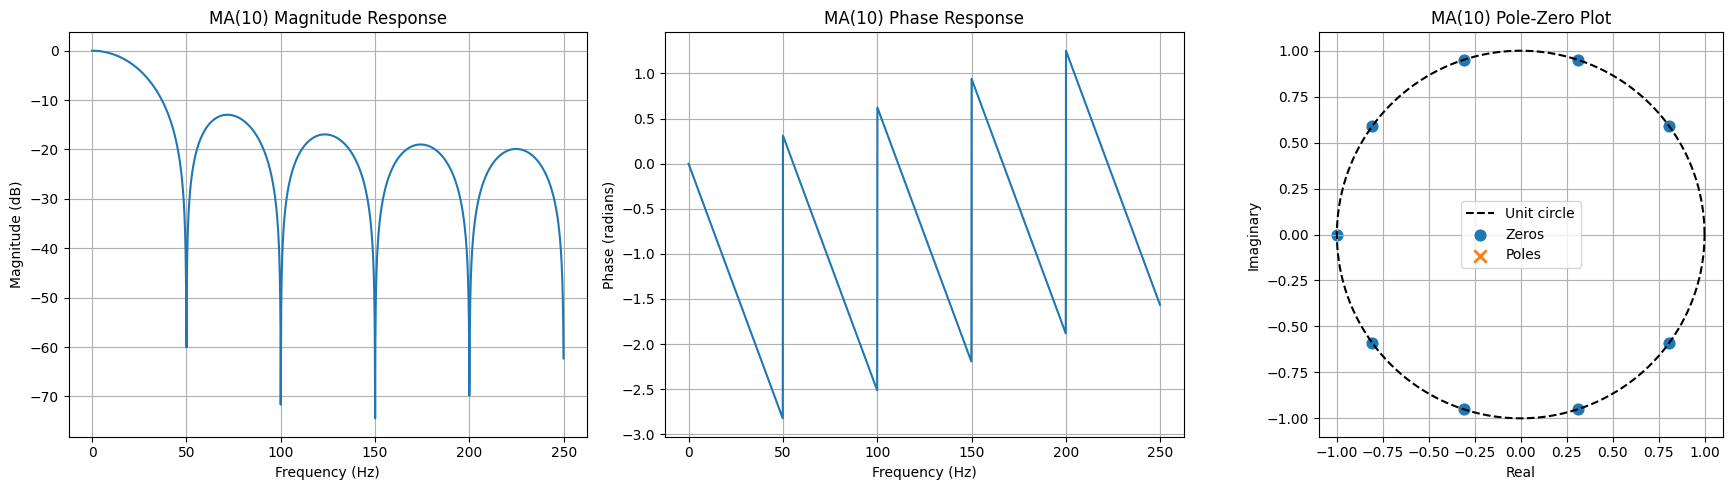

Zeros: [ 0.80901699+0.58778525j  0.80901699-0.58778525j  0.30901699+0.95105652j
  0.30901699-0.95105652j -1.        +0.j         -0.80901699+0.58778525j
 -0.80901699-0.58778525j -0.30901699+0.95105652j -0.30901699-0.95105652j]
Poles: []


In [21]:
# MA(10) filter using scipy.signal.lfilter
N = 10
b10 = np.ones(N) / N
a10 = np.array([1.0])

# Frequency and phase response
w10, h10 = freqz(b10, a10, worN=2048, fs=sampling_frequency)

magnitude_ma10_db = 20 * np.log10(
    np.maximum(np.abs(h10), np.finfo(float).eps)
)
phase_ma10 = np.unwrap(np.angle(h10))

# Zeros and poles
zeros_ma10 = np.roots(b10)
poles_ma10 = np.roots(a10)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

axes[0].plot(w10, magnitude_ma10_db)
axes[0].set_title("MA(10) Magnitude Response")
axes[0].set_xlabel("Frequency (Hz)")
axes[0].set_ylabel("Magnitude (dB)")
axes[0].grid(True)

axes[1].plot(w10, phase_ma10)
axes[1].set_title("MA(10) Phase Response")
axes[1].set_xlabel("Frequency (Hz)")
axes[1].set_ylabel("Phase (radians)")
axes[1].grid(True)

axes[2].plot(np.cos(theta), np.sin(theta), "k--", label="Unit circle")
axes[2].scatter(
    zeros_ma10.real,
    zeros_ma10.imag,
    marker="o",
    s=60,
    label="Zeros"
)
axes[2].scatter(
    poles_ma10.real,
    poles_ma10.imag,
    marker="x",
    s=80,
    linewidths=2,
    label="Poles"
)
axes[2].set_aspect("equal", adjustable="box")
axes[2].set_title("MA(10) Pole-Zero Plot")
axes[2].set_xlabel("Real")
axes[2].set_ylabel("Imaginary")
axes[2].grid(True)
axes[2].legend()

plt.tight_layout()
plt.show()

print("Zeros:", zeros_ma10)
print("Poles:", poles_ma10)



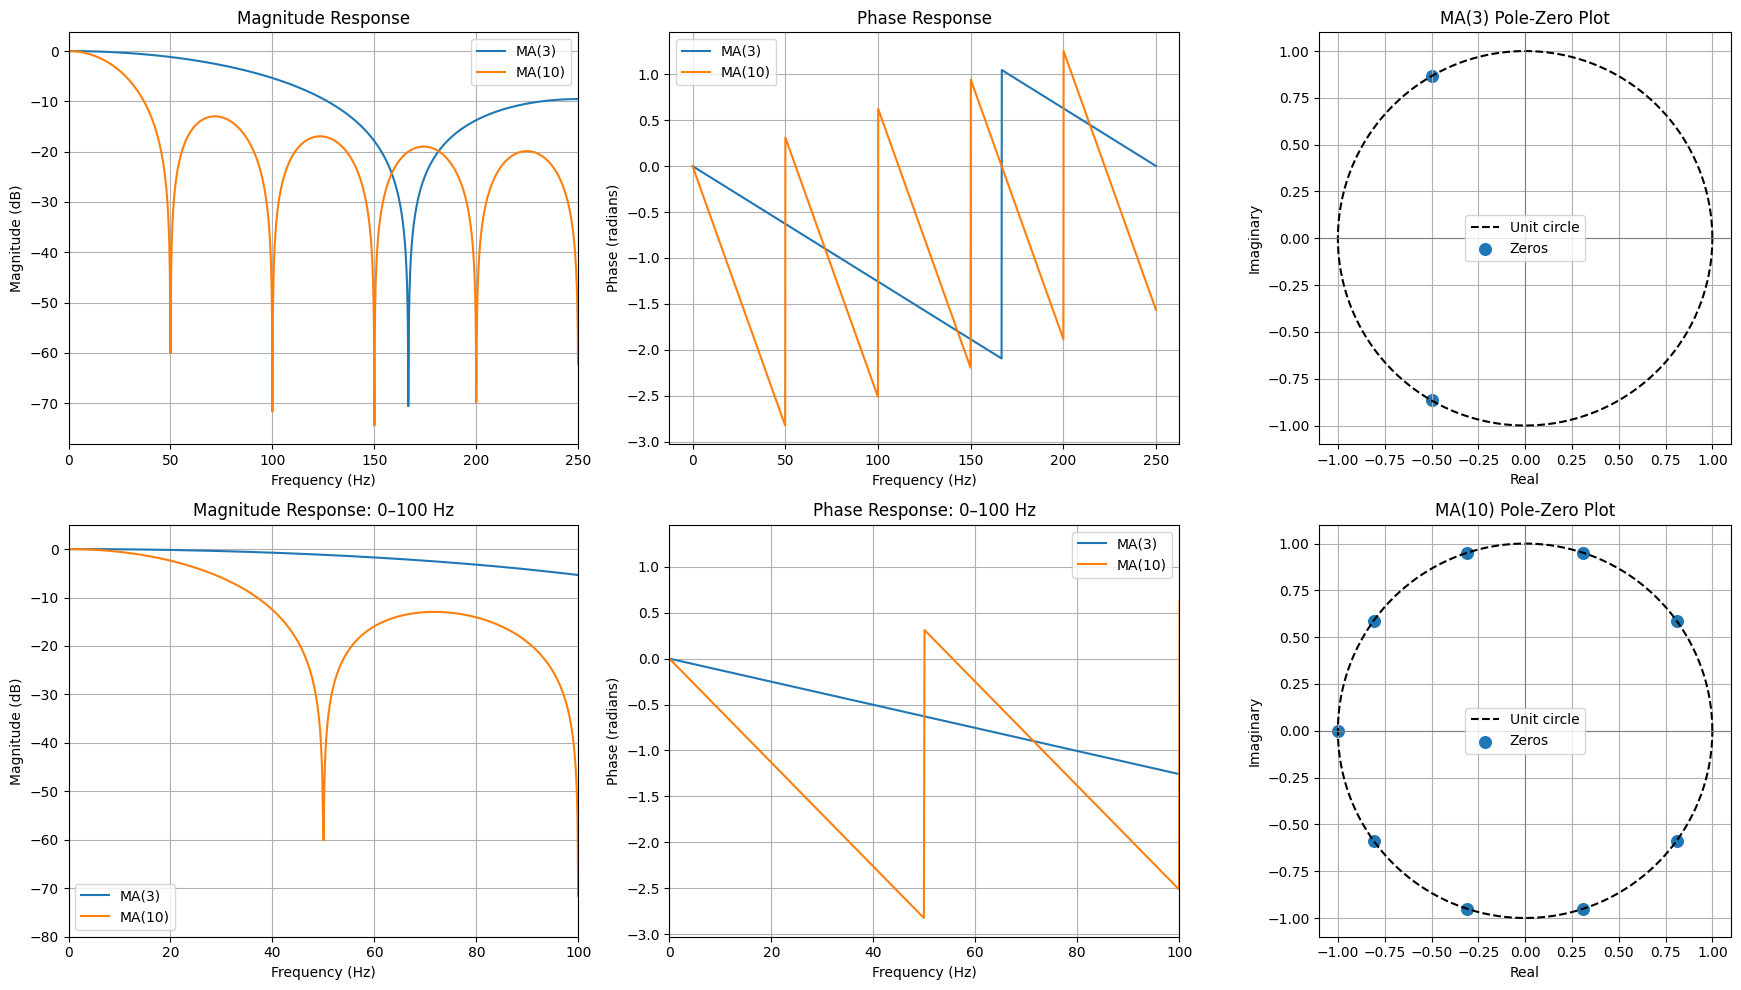

10 Hz: MA(3) =  -0.05 dB, MA(10) =  -0.57 dB
20 Hz: MA(3) =  -0.18 dB, MA(10) =  -2.40 dB
40 Hz: MA(3) =  -0.75 dB, MA(10) = -12.53 dB

First magnitude null:
MA(3):  166.7 Hz
MA(10): 50.0 Hz

Group delays:
MA(3):  1 sample
MA(10): 4.5 samples


In [23]:
# Compare MA(3) and MA(10) frequency responses and pole-zero locations
w3, h3 = freqz(b, a, worN=2048, fs=sampling_frequency)
w10, h10 = freqz(b10, a10, worN=2048, fs=sampling_frequency)

magnitude_ma3_db = 20 * np.log10(np.maximum(np.abs(h3), np.finfo(float).eps))
magnitude_ma10_db = 20 * np.log10(np.maximum(np.abs(h10), np.finfo(float).eps))

phase_ma3 = np.unwrap(np.angle(h3))
phase_ma10 = np.unwrap(np.angle(h10))

zeros_ma3 = np.roots(b)
poles_ma3 = np.roots(a)
zeros_ma10 = np.roots(b10)
poles_ma10 = np.roots(a10)

fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# Magnitude response
axes[0, 0].plot(w3, magnitude_ma3_db, label="MA(3)")
axes[0, 0].plot(w10, magnitude_ma10_db, label="MA(10)")
axes[0, 0].set_title("Magnitude Response")
axes[0, 0].set_xlabel("Frequency (Hz)")
axes[0, 0].set_ylabel("Magnitude (dB)")
axes[0, 0].set_xlim(0, sampling_frequency / 2)
axes[0, 0].grid(True)
axes[0, 0].legend()

# Phase response
axes[0, 1].plot(w3, phase_ma3, label="MA(3)")
axes[0, 1].plot(w10, phase_ma10, label="MA(10)")
axes[0, 1].set_title("Phase Response")
axes[0, 1].set_xlabel("Frequency (Hz)")
axes[0, 1].set_ylabel("Phase (radians)")
axes[0, 1].grid(True)
axes[0, 1].legend()

# Pole-zero comparison
unit_circle = np.exp(1j * theta)

for ax, zeros_filter, poles_filter, title in [
    (axes[0, 2], zeros_ma3, poles_ma3, "MA(3) Pole-Zero Plot"),
    (axes[1, 2], zeros_ma10, poles_ma10, "MA(10) Pole-Zero Plot"),
]:
    ax.plot(unit_circle.real, unit_circle.imag, "k--", label="Unit circle")
    ax.scatter(zeros_filter.real, zeros_filter.imag, s=70, label="Zeros")

    if poles_filter.size:
        ax.scatter(
            poles_filter.real,
            poles_filter.imag,
            marker="x",
            s=90,
            linewidths=2,
            label="Poles",
        )

    ax.axhline(0, color="gray", linewidth=0.8)
    ax.axvline(0, color="gray", linewidth=0.8)
    ax.set_aspect("equal", adjustable="box")
    ax.set_title(title)
    ax.set_xlabel("Real")
    ax.set_ylabel("Imaginary")
    ax.grid(True)
    ax.legend()

# Zoomed magnitude response
axes[1, 0].plot(w3, magnitude_ma3_db, label="MA(3)")
axes[1, 0].plot(w10, magnitude_ma10_db, label="MA(10)")
axes[1, 0].set_title("Magnitude Response: 0–100 Hz")
axes[1, 0].set_xlabel("Frequency (Hz)")
axes[1, 0].set_ylabel("Magnitude (dB)")
axes[1, 0].set_xlim(0, 100)
axes[1, 0].set_ylim(-80, 5)
axes[1, 0].grid(True)
axes[1, 0].legend()

# Zoomed phase response
axes[1, 1].plot(w3, phase_ma3, label="MA(3)")
axes[1, 1].plot(w10, phase_ma10, label="MA(10)")
axes[1, 1].set_title("Phase Response: 0–100 Hz")
axes[1, 1].set_xlabel("Frequency (Hz)")
axes[1, 1].set_ylabel("Phase (radians)")
axes[1, 1].set_xlim(0, 100)
axes[1, 1].grid(True)
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# Useful comparison values
for frequency in [10, 20, 40]:
    gain_ma3 = np.interp(frequency, w3, magnitude_ma3_db)
    gain_ma10 = np.interp(frequency, w10, magnitude_ma10_db)
    print(
        f"{frequency:>2} Hz: "
        f"MA(3) = {gain_ma3:6.2f} dB, "
        f"MA(10) = {gain_ma10:6.2f} dB"
    )

print("\nFirst magnitude null:")
print(f"MA(3):  {sampling_frequency / 3:.1f} Hz")
print(f"MA(10): {sampling_frequency / 10:.1f} Hz")

print("\nGroup delays:")
print("MA(3):  1 sample")
print("MA(10): 4.5 samples")

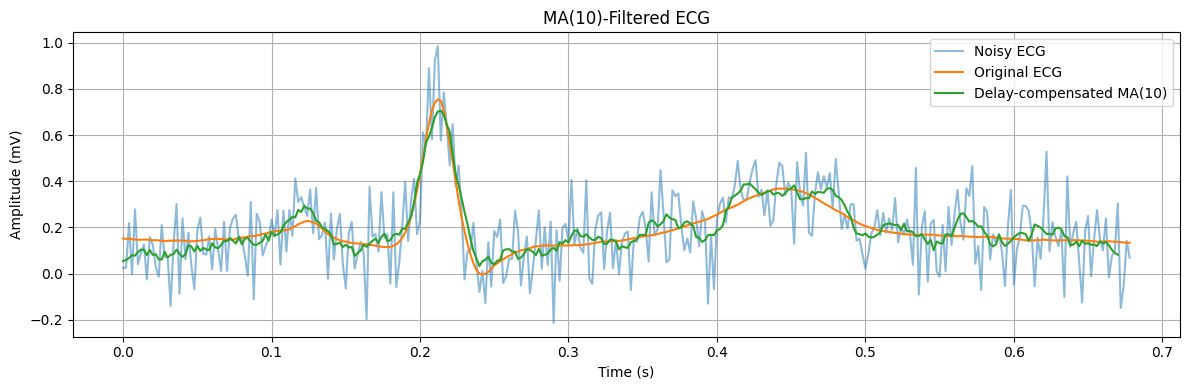

In [22]:
ma10ECG_lfilter = lfilter(b10, a10, nECG)

# Compensate for the MA(10) group delay: (10 - 1) / 2 = 4.5 samples
delay_ma10 = (N - 1) // 2
ma10ECG = ma10ECG_lfilter[delay_ma10:]

# Plot the delay-compensated filtered signal
plt.figure(figsize=(12, 4))
plt.plot(time, nECG, label="Noisy ECG", alpha=0.5)
plt.plot(time, ecg_signal, label="Original ECG")
plt.plot(
    time[:ma10ECG.size],
    ma10ECG,
    label="Delay-compensated MA(10)",
    linewidth=1.5
)
plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("MA(10)-Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()



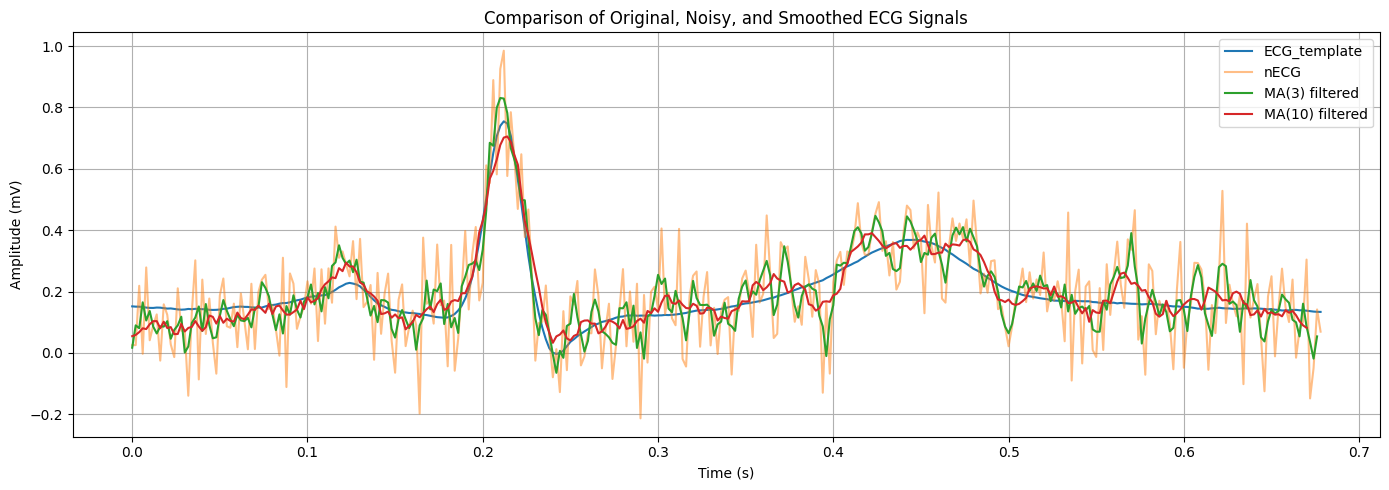

In [24]:
plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, nECG, label="nECG", alpha=0.5)
plt.plot(
    time[:ma3ECG_2.size],
    ma3ECG_2,
    label="MA(3) filtered",
    linewidth=1.5
)
plt.plot(
    time[:ma10ECG.size],
    ma10ECG,
    label="MA(10) filtered",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Original, Noisy, and Smoothed ECG Signals")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Optimum MA(N) Filter Order

In [25]:
def ma_filter_mse(noise_free_signal, filtered_signal, N):
    """
    Calculate the MSE between a noise-free signal and an MA(N)-filtered signal.

    The MA(N) group delay is compensated before calculating the error.
    """
    noise_free_signal = np.asarray(noise_free_signal, dtype=float)
    filtered_signal = np.asarray(filtered_signal, dtype=float)

    if N < 1 or N != int(N):
        raise ValueError("N must be a positive integer")

    delay = (N - 1) / 2
    sample_indices = np.arange(filtered_signal.size)
    reference_indices = sample_indices - delay

    valid = (
        (reference_indices >= 0)
        & (reference_indices < noise_free_signal.size)
        & (sample_indices >= N - 1)
    )

    reference = np.interp(
        reference_indices[valid],
        np.arange(noise_free_signal.size),
        noise_free_signal,
    )

    error = reference - filtered_signal[valid]
    return np.mean(error**2)

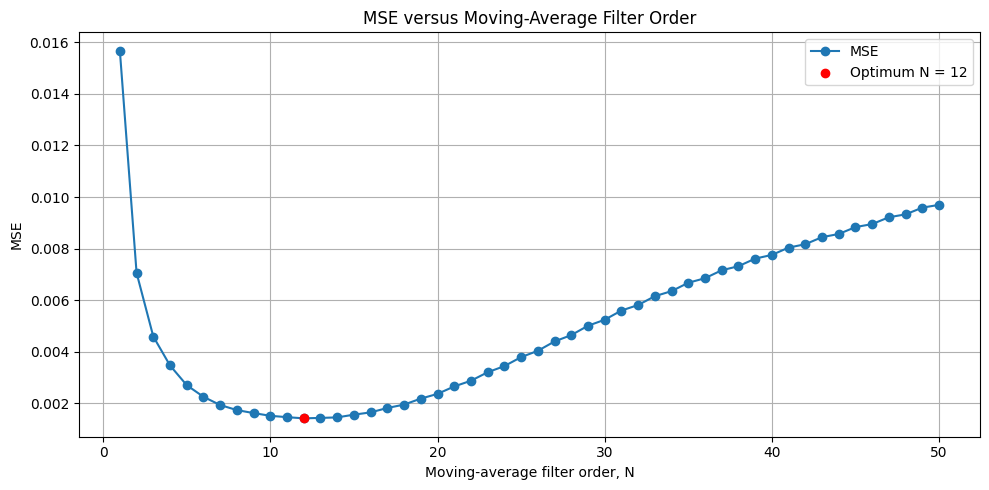

Optimal filter order: N = 12
Minimum MSE: 0.001411


In [26]:
# Test MA filter orders and calculate the delay-compensated MSE
N_values = np.arange(1, 51)
mse_values = []

for order in N_values:
    coefficients = np.ones(order) / order
    filtered_signal = lfilter(coefficients, [1.0], nECG)

    mse = ma_filter_mse(ecg_signal, filtered_signal, order)
    mse_values.append(mse)

mse_values = np.asarray(mse_values)

optimal_index = np.argmin(mse_values)
optimal_N = N_values[optimal_index]
minimum_mse = mse_values[optimal_index]

plt.figure(figsize=(10, 5))
plt.plot(N_values, mse_values, "o-", label="MSE")
plt.scatter(
    optimal_N,
    minimum_mse,
    color="red",
    zorder=3,
    label=f"Optimum N = {optimal_N}"
)

plt.xlabel("Moving-average filter order, N")
plt.ylabel("MSE")
plt.title("MSE versus Moving-Average Filter Order")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal filter order: N = {optimal_N}")
print(f"Minimum MSE: {minimum_mse:.6f}")

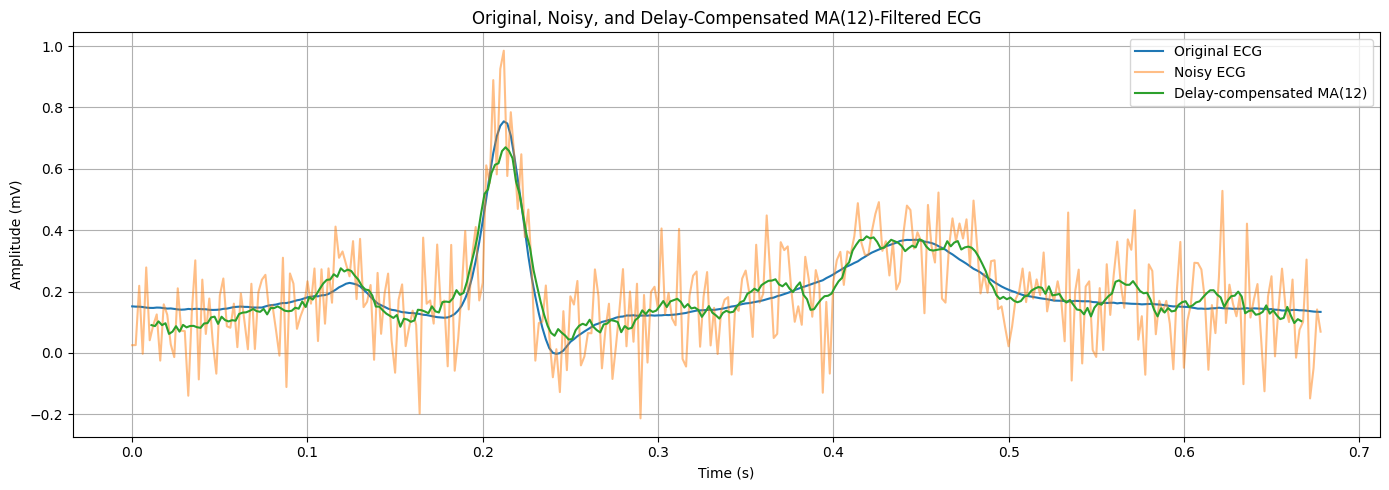

In [27]:
# MA(12) filter with delay compensation
N12 = 12
b12 = np.ones(N12) / N12
a12 = np.array([1.0])

ma12ECG_lfilter = lfilter(b12, a12, nECG)

# MA(12) group delay: (12 - 1) / 2 = 5.5 samples
delay_ma12 = (N12 - 1) / 2
valid = np.arange(N12 - 1, ma12ECG_lfilter.size)
compensated_time = time[valid] - delay_ma12 / sampling_frequency

plt.figure(figsize=(14, 5))
plt.plot(time, ecg_signal, label="Original ECG", linewidth=1.5)
plt.plot(time, nECG, label="Noisy ECG", alpha=0.5)
plt.plot(
    compensated_time,
    ma12ECG_lfilter[valid],
    label="Delay-compensated MA(12)",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Original, Noisy, and Delay-Compensated MA(12)-Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

## Savitzky-Golay Filter

In [28]:
from scipy.signal import savgol_filter

sg311ECG = savgol_filter(nECG, window_length=11, polyorder=3)

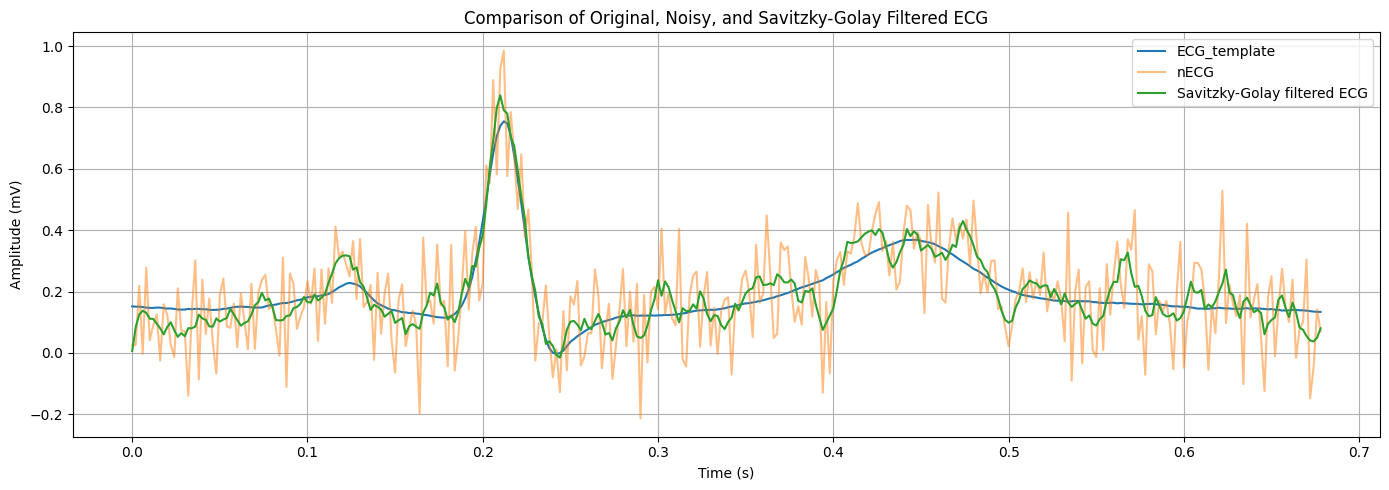

In [29]:
plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, nECG, label="nECG", alpha=0.5)
plt.plot(time, sg311ECG, label="Savitzky-Golay filtered ECG", linewidth=1.5)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Original, Noisy, and Savitzky-Golay Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

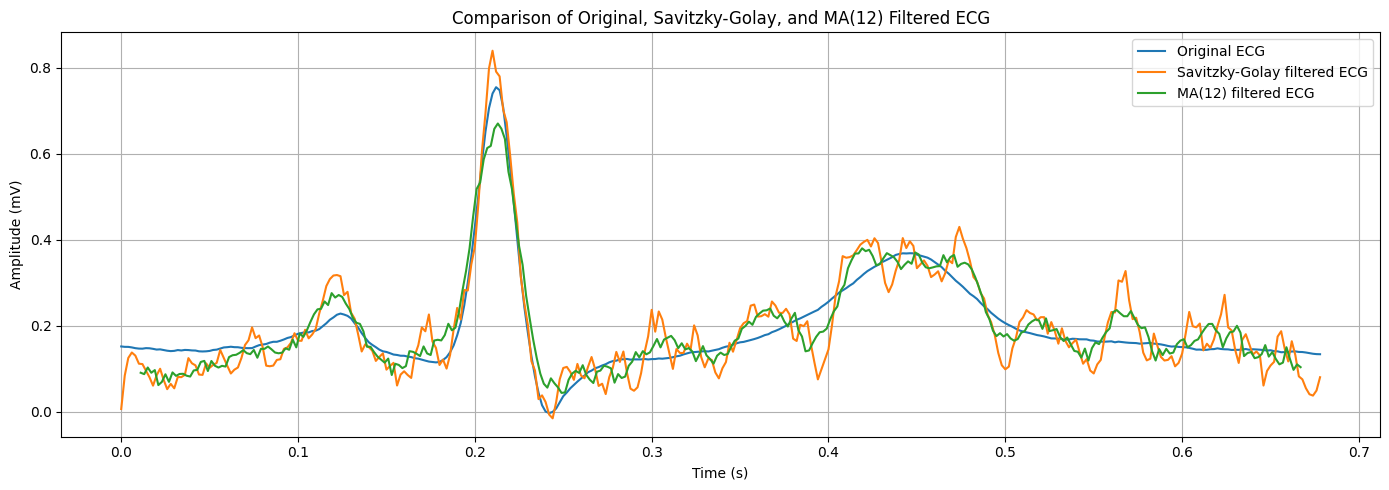

In [31]:
plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="Original ECG", linewidth=1.5)
plt.plot(time, sg311ECG, label="Savitzky-Golay filtered ECG", linewidth=1.5)

# Delay-compensated MA(12)
plt.plot(
    compensated_time,
    ma12ECG_lfilter[valid],
    label="MA(12) filtered ECG",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Original, Savitzky-Golay, and MA(12) Filtered ECG")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

### Optimum SG(N,L) filter parameters

In [32]:
def sg_filter_mse(reference_signal, noisy_signal, window_length, polyorder):
    """
    Calculate the MSE of a Savitzky-Golay filtered signal.

    Edge samples are excluded because Savitzky-Golay edge handling can
    introduce boundary effects.
    """
    reference_signal = np.asarray(reference_signal, dtype=float)
    noisy_signal = np.asarray(noisy_signal, dtype=float)

    if window_length % 2 == 0 or window_length < 3:
        raise ValueError("window_length must be an odd integer >= 3")

    if polyorder < 0 or polyorder >= window_length:
        raise ValueError("polyorder must satisfy 0 <= polyorder < window_length")

    if reference_signal.size != noisy_signal.size:
        raise ValueError("Signals must have the same length")

    filtered_signal = savgol_filter(
        noisy_signal,
        window_length=window_length,
        polyorder=polyorder
    )

    half_window = window_length // 2
    valid_slice = slice(half_window, -half_window)

    error = (
        reference_signal[valid_slice]
        - filtered_signal[valid_slice]
    )

    return np.mean(error**2)


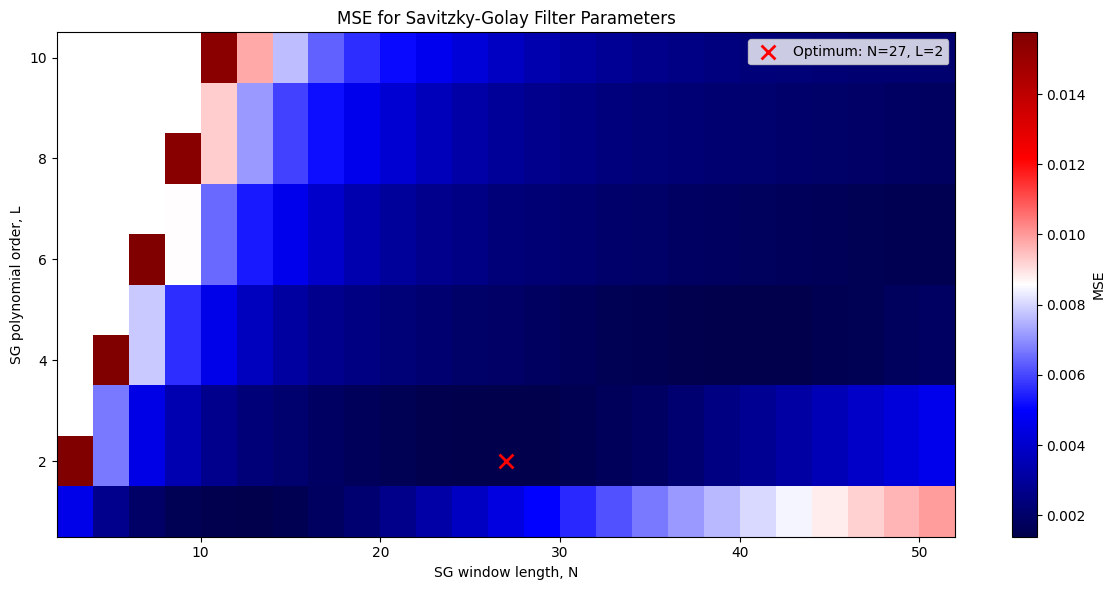

Optimal window length, N: 27
Optimal polynomial order, L: 2
Minimum MSE: 0.00139175


In [35]:

# Parameter ranges
window_lengths = np.arange(3, 52, 2)
polyorders = np.arange(1, 11)

mse_grid = np.full(
    (polyorders.size, window_lengths.size),
    np.nan
)

for row, polyorder in enumerate(polyorders):
    for col, window_length in enumerate(window_lengths):
        if polyorder < window_length:
            mse_grid[row, col] = sg_filter_mse(
                ecg_signal,
                nECG,
                window_length,
                polyorder
            )

# Find optimum parameters
optimal_row, optimal_col = np.unravel_index(
    np.nanargmin(mse_grid),
    mse_grid.shape
)

optimal_window_length = window_lengths[optimal_col]
optimal_polyorder = polyorders[optimal_row]
minimum_mse = mse_grid[optimal_row, optimal_col]

# Plot MSE surface
plt.figure(figsize=(12, 6))

mesh = plt.pcolormesh(
    window_lengths,
    polyorders,
    mse_grid,
    shading="auto",
    cmap="seismic"
)

plt.scatter(
    optimal_window_length,
    optimal_polyorder,
    color="red",
    marker="x",
    s=100,
    linewidths=2,
    label=(
        f"Optimum: N={optimal_window_length}, "
        f"L={optimal_polyorder}"
    )
)

plt.colorbar(mesh, label="MSE")
plt.xlabel("SG window length, N")
plt.ylabel("SG polynomial order, L")
plt.title("MSE for Savitzky-Golay Filter Parameters")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Optimal window length, N: {optimal_window_length}")
print(f"Optimal polynomial order, L: {optimal_polyorder}")
print(f"Minimum MSE: {minimum_mse:.8f}")

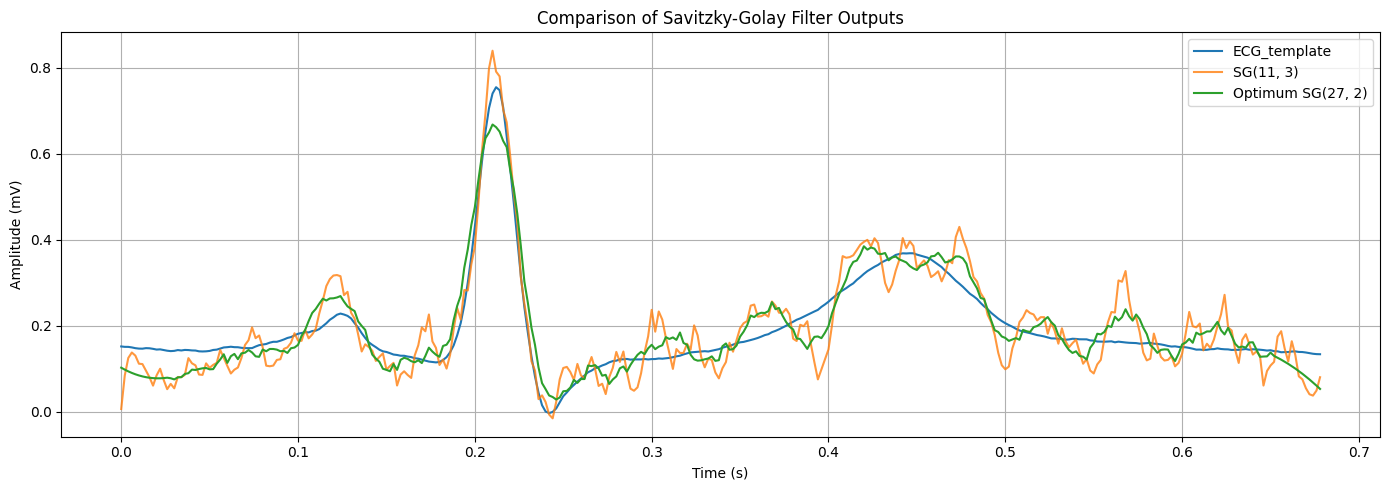

In [36]:
# Apply the optimum Savitzky-Golay filter
optimal_sgECG = savgol_filter(
    nECG,
    window_length=optimal_window_length,
    polyorder=optimal_polyorder
)

plt.figure(figsize=(14, 5))

plt.plot(time, ecg_signal, label="ECG_template", linewidth=1.5)
plt.plot(time, sg311ECG, label="SG(11, 3)", alpha=0.8)
plt.plot(
    time,
    optimal_sgECG,
    label=f"Optimum SG({optimal_window_length}, {optimal_polyorder})",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Comparison of Savitzky-Golay Filter Outputs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(14, 5))

plt.plot(
    time,
    ecg_signal,
    label="Original ECG",
    linewidth=1.5
)

plt.plot(
    compensated_time,
    ma12ECG_lfilter[valid],
    label="Optimal MA(12)",
    linewidth=1.5
)

plt.plot(
    time,
    optimal_sgECG,
    label=f"Optimal SG({optimal_window_length}, {optimal_polyorder})",
    linewidth=1.5
)

plt.xlabel("Time (s)")
plt.ylabel(f"Amplitude ({amplitude_units})")
plt.title("Original ECG and Optimal Filter Outputs")
plt.grid(True)
plt.legend()
plt.tight_layout()
plt.show()